# Supernovae Cosmology
### Measuring Cosmological Parameters Using Type Ia Supernovae

This project uses the Pantheon+SH0ES dataset of Type Ia supernovae to study the expansion of the Universe.

The analysis focuses on:

- Plotting the Hubble diagram
- Estimating the Hubble constant $H_0$
- Estimating the matter density $\Omega_m$
- Estimating the age of the Universe
- Studying model residuals
- Comparing low-redshift and high-redshift supernovae

## 1. Setup

The analysis uses NumPy and Pandas for data handling, Matplotlib for visualization, and SciPy for numerical integration and model fitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.optimize import curve_fit

## 2. Load the Dataset

The Pantheon+SH0ES dataset contains Type Ia supernova observations, including redshift, distance modulus, and measurement uncertainties.

The dataset file is kept in the same folder as this notebook.

In [5]:
import pandas as pd

file_path = "Pantheon+SH0ES.dat"

df = pd.read_csv(
    file_path,
    sep=r'\s+',
    comment='#'
)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1701 entries, 0 to 1700
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CID                   1701 non-null   object 
 1   IDSURVEY              1701 non-null   int64  
 2   zHD                   1701 non-null   float64
 3   zHDERR                1701 non-null   float64
 4   zCMB                  1701 non-null   float64
 5   zCMBERR               1701 non-null   float64
 6   zHEL                  1701 non-null   float64
 7   zHELERR               1701 non-null   float64
 8   m_b_corr              1701 non-null   float64
 9   m_b_corr_err_DIAG     1701 non-null   float64
 10  MU_SH0ES              1701 non-null   float64
 11  MU_SH0ES_ERR_DIAG     1701 non-null   float64
 12  CEPH_DIST             1701 non-null   float64
 13  IS_CALIBRATOR         1701 non-null   int64  
 14  USED_IN_SH0ES_HF      1701 non-null   int64  
 15  c                    

## 3. Select the Required Data

For this analysis, we only need the redshift, distance modulus, and its uncertainty.

In [6]:
df = df[
    ['zHD', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG']
].dropna()

In [7]:
df = df[
    (df['zHD'] > 0) &
    (df['MU_SH0ES_ERR_DIAG'] > 0)
]

## 4. Hubble Diagram

The Hubble diagram shows the relationship between redshift and distance modulus.

The redshift axis is shown on a logarithmic scale because the dataset covers a wide range of redshifts.

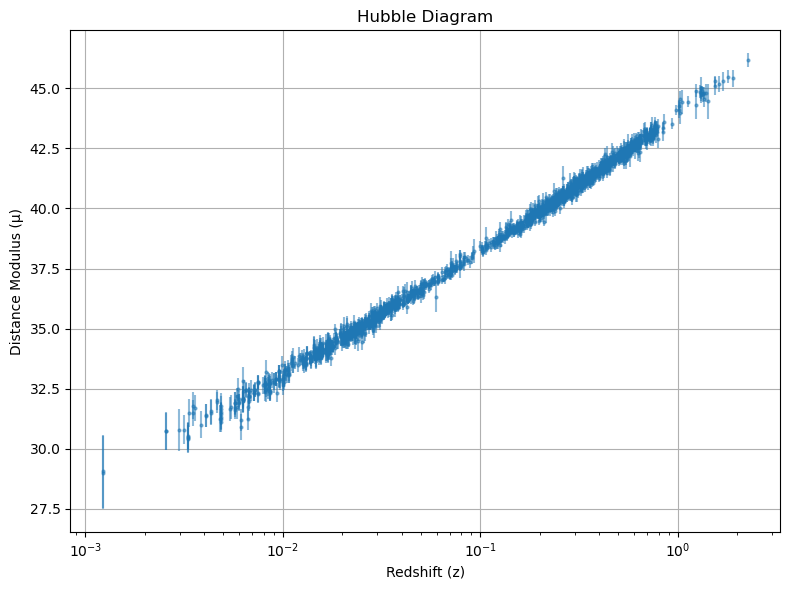

In [8]:
plt.figure(figsize=(8, 6))

plt.errorbar(
    df['zHD'],
    df['MU_SH0ES'],
    yerr=df['MU_SH0ES_ERR_DIAG'],
    fmt='o',
    markersize=2,
    alpha=0.5
)

plt.xscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('Distance Modulus (μ)')
plt.title('Hubble Diagram')

plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

The distance modulus increases with redshift, showing that more distant supernovae appear fainter. This relationship provides the observational basis for constraining cosmological parameters.

## 5. Cosmological Model

We use a flat ΛCDM model to describe the expansion of the Universe.

The expansion function is

$$
E(z) = \sqrt{\Omega_m(1+z)^3 + (1-\Omega_m)}
$$

The luminosity distance is

$$
d_L(z) =
\frac{c(1+z)}{H_0}
\int_0^z \frac{dz'}{E(z')}
$$

The theoretical distance modulus is

$$
\mu = 5\log_{10}(d_L) + 25
$$

where $d_L$ is measured in Mpc.

In [9]:
c = 299792.458  # km/s

def E(z, Omega_m):
    return np.sqrt(
        Omega_m * (1 + z)**3 + (1 - Omega_m)
    )


def luminosity_distance(z, H0, Omega_m):
    integral, _ = quad(
        lambda z: 1 / E(z, Omega_m),
        0,
        z
    )

    return (c / H0) * (1 + z) * integral


def mu_theory(z, H0, Omega_m):
    return np.array([
        5 * np.log10(
            luminosity_distance(zi, H0, Omega_m)
        ) + 25
        for zi in z
    ])

## 6. Fit the Cosmological Parameters

We now fit the model to the observed distance modulus.

The two parameters being estimated are:

- $H_0$ — Hubble constant
- $\Omega_m$ — matter density parameter

The initial values are $H_0 = 70$ km/s/Mpc and $\Omega_m = 0.3$.

In [10]:
z_data = df['zHD'].values
mu_data = df['MU_SH0ES'].values
mu_error = df['MU_SH0ES_ERR_DIAG'].values

initial_guess = [70, 0.3]

popt, pcov = curve_fit(
    mu_theory,
    z_data,
    mu_data,
    sigma=mu_error,
    p0=initial_guess,
    absolute_sigma=True
)

H0_fit, Omega_m_fit = popt

H0_error, Omega_m_error = np.sqrt(
    np.diag(pcov)
)

print(f"H0 = {H0_fit:.2f} ± {H0_error:.2f} km/s/Mpc")
print(f"Omega_m = {Omega_m_fit:.3f} ± {Omega_m_error:.3f}")

H0 = 72.97 ± 0.26 km/s/Mpc
Omega_m = 0.351 ± 0.019


## 7. Best-Fit Model

The fitted ΛCDM model is compared with the observed supernova data.

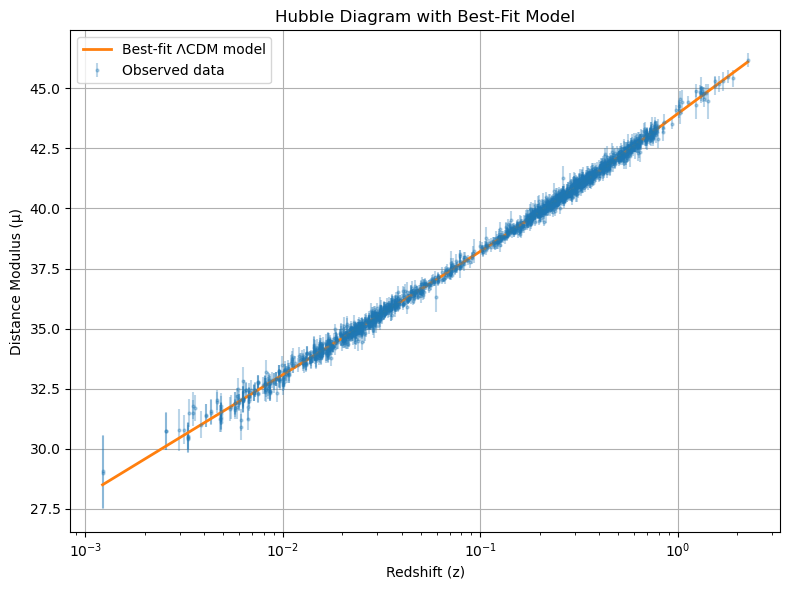

In [11]:
z_model = np.logspace(
    np.log10(z_data.min()),
    np.log10(z_data.max()),
    200
)

mu_model = mu_theory(
    z_model,
    H0_fit,
    Omega_m_fit
)

plt.figure(figsize=(8, 6))

plt.errorbar(
    z_data,
    mu_data,
    yerr=mu_error,
    fmt='o',
    markersize=2,
    alpha=0.3,
    label='Observed data'
)

plt.plot(
    z_model,
    mu_model,
    linewidth=2,
    label='Best-fit ΛCDM model'
)

plt.xscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('Distance Modulus (μ)')
plt.title('Hubble Diagram with Best-Fit Model')

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

The fitted ΛCDM curve follows the overall trend of the observed supernova data. The remaining differences between the observations and the model can be examined using residuals.

## 8. Estimate the Age of the Universe

For a flat ΛCDM model, the age of the Universe can be estimated from the fitted values of $H_0$ and $\Omega_m$.

In [12]:
def universe_age(H0, Omega_m):

    integral, _ = quad(
        lambda z: 1 / ((1 + z) * E(z, Omega_m)),
        0,
        1000
    )

    H0_per_second = H0 / 3.085677581e19

    age_seconds = integral / H0_per_second

    age_years = age_seconds / (365.25 * 24 * 3600)

    return age_years / 1e9


age = universe_age(
    H0_fit,
    Omega_m_fit
)

print(f"Estimated age of the Universe = {age:.2f} Gyr")

Estimated age of the Universe = 12.36 Gyr


## 9. Residual Analysis

Residuals show the difference between the observed distance modulus and the value predicted by the fitted model.

$$
Residual = \mu_{observed} - \mu_{model}
$$

Residuals close to zero indicate good agreement between the model and observations.

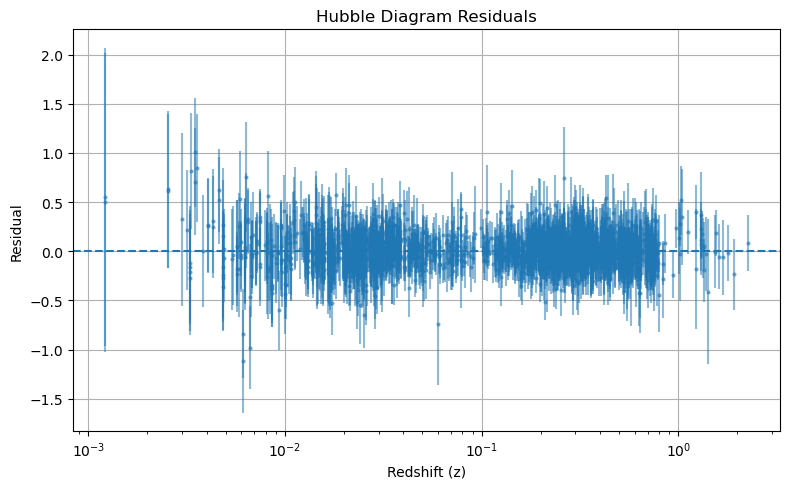

In [13]:
mu_fitted = mu_theory(
    z_data,
    H0_fit,
    Omega_m_fit
)

residuals = mu_data - mu_fitted

plt.figure(figsize=(8, 5))

plt.errorbar(
    z_data,
    residuals,
    yerr=mu_error,
    fmt='o',
    markersize=2,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle='--'
)

plt.xscale('log')
plt.xlabel('Redshift (z)')
plt.ylabel('Residual')
plt.title('Hubble Diagram Residuals')

plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

The residual plot can be used to check whether the fitted model shows any systematic deviation with redshift. A random distribution around zero is generally consistent with a reasonable model fit.

## 10. Fix $\Omega_m$ and Fit $H_0$

We now fix the matter density at $\Omega_m = 0.3$ and fit only the Hubble constant.

This allows us to examine how the estimated $H_0$ changes when the matter density is fixed.

In [14]:
def mu_fixed_omega(z, H0):
    return mu_theory(
        z,
        H0,
        0.3
    )


popt_fixed, pcov_fixed = curve_fit(
    mu_fixed_omega,
    z_data,
    mu_data,
    sigma=mu_error,
    p0=[70],
    absolute_sigma=True
)

H0_fixed = popt_fixed[0]

H0_fixed_error = np.sqrt(
    pcov_fixed[0, 0]
)

print(
    f"H0 = {H0_fixed:.2f} ± "
    f"{H0_fixed_error:.2f} km/s/Mpc"
)

H0 = 73.53 ± 0.17 km/s/Mpc


## 11. Low-z and High-z Comparison

To examine whether the inferred Hubble constant changes with redshift, the data are divided into two groups:

- Low-z: $z < 0.1$
- High-z: $z \geq 0.1$

For both groups, $\Omega_m$ is fixed at 0.3.

In [15]:
z_split = 0.1

low_z = df['zHD'] < z_split
high_z = df['zHD'] >= z_split

In [16]:
low_fit, low_cov = curve_fit(
    mu_fixed_omega,
    df.loc[low_z, 'zHD'],
    df.loc[low_z, 'MU_SH0ES'],
    sigma=df.loc[low_z, 'MU_SH0ES_ERR_DIAG'],
    p0=[70],
    absolute_sigma=True
)

high_fit, high_cov = curve_fit(
    mu_fixed_omega,
    df.loc[high_z, 'zHD'],
    df.loc[high_z, 'MU_SH0ES'],
    sigma=df.loc[high_z, 'MU_SH0ES_ERR_DIAG'],
    p0=[70],
    absolute_sigma=True
)

H0_low = low_fit[0]
H0_high = high_fit[0]

print(f"Low-z H0 = {H0_low:.2f} km/s/Mpc")
print(f"High-z H0 = {H0_high:.2f} km/s/Mpc")

Low-z H0 = 73.01 km/s/Mpc
High-z H0 = 73.85 km/s/Mpc


## 12. Final Results

The main results from the analysis are:

- Best-fit $H_0$
- Best-fit $\Omega_m$
- Estimated age of the Universe
- $H_0$ with fixed $\Omega_m$
- Low-z $H_0$
- High-z $H_0$

In [17]:
print(f"H0 = {H0_fit:.2f} ± {H0_error:.2f} km/s/Mpc")
print(f"Omega_m = {Omega_m_fit:.3f} ± {Omega_m_error:.3f}")
print(f"Universe age = {age:.2f} Gyr")
print(f"H0 (Omega_m = 0.3) = {H0_fixed:.2f} ± {H0_fixed_error:.2f} km/s/Mpc")
print(f"H0 (low-z) = {H0_low:.2f} km/s/Mpc")
print(f"H0 (high-z) = {H0_high:.2f} km/s/Mpc")

H0 = 72.97 ± 0.26 km/s/Mpc
Omega_m = 0.351 ± 0.019
Universe age = 12.36 Gyr
H0 (Omega_m = 0.3) = 73.53 ± 0.17 km/s/Mpc
H0 (low-z) = 73.01 km/s/Mpc
H0 (high-z) = 73.85 km/s/Mpc


## 13. Conclusion

The Pantheon+SH0ES supernova data were used to construct the Hubble diagram and fit a flat ΛCDM cosmological model.

The analysis provides estimates of the Hubble constant, matter density, and the age of the Universe. Residuals and redshift-based comparisons were also used to examine the consistency of the fitted model.

The results depend on the dataset, uncertainties, and assumptions of the cosmological model used in the analysis.